In [3]:
# ============================================================
# EPL Transformer Trajectory Model (NO-ODDS) — RESUMABLE
# - Continues training from latest checkpoint if it exists
# - Saves: model, optimizer, epoch, best_test, best_state
# - Optional: also saves temperature scaler (after calibration)
# ============================================================

import os
import math
import random
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------- CONFIG --------------------
CSV_PATH    = "epl_master_train_full.csv"
MIN_DATE    = "2005-01-01"
NAN_THRESH  = 0.90
RANDOM_SEED = 42

SEQ_LEN     = 12
BATCH_SIZE  = 256
EPOCHS      = 15
LR          = 2e-4
WEIGHT_DECAY= 1e-2

D_MODEL     = 96
N_HEAD      = 4
N_LAYERS    = 3
D_FF        = 256
DROPOUT     = 0.2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---- checkpointing ----
CKPT_DIR = "checkpoints_epl_traj"
CKPT_PREFIX = "epl_traj"
os.makedirs(CKPT_DIR, exist_ok=True)

RESUME = True  # set False to force fresh training
SAVE_EVERY_EPOCH = False

fixtures = [
    ("2026-02-28", "Wolves",       "Aston Villa"),
    ("2026-02-28", "Bournemouth",  "Sunderland"),
    ("2026-02-28", "Newcastle",    "Everton"),
    ("2026-02-28", "Burnley",      "Brentford"),
    ("2026-02-28", "Liverpool",    "West Ham"),
    ("2026-02-28", "Leeds",        "Man City"),
]
fixtures_df = pd.DataFrame(fixtures, columns=["date","home_team","away_team"])
fixtures_df["date"] = pd.to_datetime(fixtures_df["date"])

# -------------------- helper: team name cleaning --------------------
def clean_team_name(x: str) -> str:
    if pd.isna(x):
        return x
    s = str(x).strip()
    repl = {
        "Wolverhampton": "Wolves",
        "Manchester City": "Man City",
        "Manchester United": "Man United",
        "West Ham United": "West Ham",
        "Nott'm Forest": "Nottm Forest",
        "Nottingham Forest": "Nottm Forest",
        "Spurs": "Tottenham",
    }
    return repl.get(s, s)

# -------------------- load + cleanup --------------------
df0 = pd.read_csv(CSV_PATH, low_memory=False)
df0["date"] = pd.to_datetime(df0["date"], errors="coerce")

rename_map = {
    "HomeTeam": "home_team", "AwayTeam": "away_team",
    "FTHG": "home_goals", "FTAG": "away_goals", "FTR": "ft_result"
}
for k, v in rename_map.items():
    if k in df0.columns and v not in df0.columns:
        df0 = df0.rename(columns={k: v})

df0 = df0.loc[:, df0.isna().mean() <= NAN_THRESH].copy()

need = ["date","home_team","away_team","home_goals","away_goals","target"]
missing = [c for c in need if c not in df0.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}\nFound: {list(df0.columns)[:30]}")

df0["home_team"] = df0["home_team"].map(clean_team_name)
df0["away_team"] = df0["away_team"].map(clean_team_name)

df0 = df0[df0["date"].notna() & (df0["date"] >= pd.to_datetime(MIN_DATE))].copy()
df0["target"] = df0["target"].astype(str).str.strip()
df0 = df0[df0["target"].isin(["H","D","A"])].copy()

df0["home_goals"] = pd.to_numeric(df0["home_goals"], errors="coerce")
df0["away_goals"] = pd.to_numeric(df0["away_goals"], errors="coerce")
df0 = df0[df0["home_goals"].notna() & df0["away_goals"].notna()].copy()

df0 = df0.sort_values("date").reset_index(drop=True)

# -------------------- points helper --------------------
def result_points(hg, ag):
    if hg > ag:  return 3, 0
    if hg < ag:  return 0, 3
    return 1, 1

# ============================================================
# 1) Build long per-team history
# ============================================================
rows = []
for i, r in df0.iterrows():
    hg, ag = float(r["home_goals"]), float(r["away_goals"])
    hp, ap = result_points(hg, ag)
    dt = r["date"]

    rows.append({
        "match_idx": i, "date": dt, "team": r["home_team"], "opp": r["away_team"],
        "is_home": 1, "gf": hg, "ga": ag, "gd": hg - ag, "pts": hp,
    })
    rows.append({
        "match_idx": i, "date": dt, "team": r["away_team"], "opp": r["home_team"],
        "is_home": 0, "gf": ag, "ga": hg, "gd": ag - hg, "pts": ap,
    })

long = pd.DataFrame(rows).sort_values(["date","match_idx","team"]).reset_index(drop=True)

# ============================================================
# 2) Compute table context strictly causal
# ============================================================
teams = sorted(pd.unique(pd.concat([df0["home_team"], df0["away_team"]], ignore_index=True)))
team_to_id = {t:i for i,t in enumerate(teams)}

points = {t: 0.0 for t in teams}
gf_tot = {t: 0.0 for t in teams}
ga_tot = {t: 0.0 for t in teams}
last_date = {t: None for t in teams}

ctx_rows = []
for i, r in df0.iterrows():
    dt = r["date"]
    ht = r["home_team"]; at = r["away_team"]
    hg = float(r["home_goals"]); ag = float(r["away_goals"])
    hp, ap = result_points(hg, ag)

    table = []
    for t in teams:
        gd = gf_tot[t] - ga_tot[t]
        table.append((t, points[t], gd, gf_tot[t]))
    table_sorted = sorted(table, key=lambda x: (x[1], x[2], x[3]), reverse=True)
    rank_map = {t: (rk+1) for rk, (t,_,_,_) in enumerate(table_sorted)}

    def rest_days(team):
        if last_date[team] is None:
            return np.nan
        return float((dt - last_date[team]).days)

    ctx_rows.append({
        "match_idx": i,
        "home_pts_pre": points[ht],
        "away_pts_pre": points[at],
        "home_rank_pre": rank_map[ht],
        "away_rank_pre": rank_map[at],
        "home_rest_days": rest_days(ht),
        "away_rest_days": rest_days(at),
    })

    points[ht] += hp; points[at] += ap
    gf_tot[ht] += hg; ga_tot[ht] += ag
    gf_tot[at] += ag; ga_tot[at] += hg
    last_date[ht] = dt; last_date[at] = dt

ctx = pd.DataFrame(ctx_rows).set_index("match_idx")
df = df0.join(ctx, how="left")

# ============================================================
# 3) Build sequences
# ============================================================
long_by_team = {t: long[long["team"] == t].sort_values(["date","match_idx"]).reset_index(drop=True) for t in teams}
TOKEN_COLS = ["is_home", "gf", "ga", "gd", "pts"]

def get_team_seq(team: str, match_idx: int):
    hist = long_by_team[team]
    past = hist[hist["match_idx"] < match_idx]
    if len(past) < SEQ_LEN:
        return None
    return past.iloc[-SEQ_LEN:][TOKEN_COLS].to_numpy(dtype=np.float32)

def build_dataset_rows():
    out_rows = []
    for i, r in df.iterrows():
        ht, at = r["home_team"], r["away_team"]
        home_seq = get_team_seq(ht, i)
        away_seq = get_team_seq(at, i)
        if home_seq is None or away_seq is None:
            continue

        out_rows.append({
            "match_idx": i,
            "home_team": ht,
            "away_team": at,
            "home_seq": home_seq,
            "away_seq": away_seq,
            "home_pts_pre": float(r["home_pts_pre"]),
            "away_pts_pre": float(r["away_pts_pre"]),
            "home_rank_pre": float(r["home_rank_pre"]),
            "away_rank_pre": float(r["away_rank_pre"]),
            "home_rest_days": float(r["home_rest_days"]) if np.isfinite(r["home_rest_days"]) else np.nan,
            "away_rest_days": float(r["away_rest_days"]) if np.isfinite(r["away_rest_days"]) else np.nan,
            "target": r["target"],
        })
    return pd.DataFrame(out_rows)

data = build_dataset_rows().sort_values("match_idx").reset_index(drop=True)

for c in ["home_rest_days","away_rest_days"]:
    med = np.nanmedian(data[c].to_numpy())
    data[c] = data[c].fillna(med)

print("Matches with enough history:", len(data), "out of", len(df0))

le = LabelEncoder()
y_enc = le.fit_transform(data["target"].values)
class_names = list(le.classes_)
print("Classes:", class_names)

# ============================================================
# 4) Time split
# ============================================================
split_idx = int(len(data) * 0.85)
train_df = data.iloc[:split_idx].copy()
test_df  = data.iloc[split_idx:].copy()

# ============================================================
# 5) Normalize using train stats
# ============================================================
token_stack = np.concatenate(train_df["home_seq"].values.tolist() + train_df["away_seq"].values.tolist(), axis=0)
tok_mean = token_stack.mean(axis=0)
tok_std  = token_stack.std(axis=0) + 1e-6

CTX_COLS = ["home_pts_pre","away_pts_pre","home_rank_pre","away_rank_pre","home_rest_days","away_rest_days"]
ctx_mat = train_df[CTX_COLS].to_numpy(dtype=np.float32)
ctx_mean = ctx_mat.mean(axis=0)
ctx_std  = ctx_mat.std(axis=0) + 1e-6

def norm_tokens(x): return (x - tok_mean) / tok_std
def norm_ctx(x):    return (x - ctx_mean) / ctx_std

# ============================================================
# 6) Dataset / Dataloader
# ============================================================
class EPLSeqDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, y: np.ndarray):
        self.f = frame.reset_index(drop=True)
        self.y = y.astype(np.int64)

    def __len__(self):
        return len(self.f)

    def __getitem__(self, idx):
        r = self.f.iloc[idx]
        home_seq = norm_tokens(r["home_seq"]).astype(np.float32)
        away_seq = norm_tokens(r["away_seq"]).astype(np.float32)
        ctx = norm_ctx(r[CTX_COLS].to_numpy(dtype=np.float32))
        home_id = team_to_id[r["home_team"]]
        away_id = team_to_id[r["away_team"]]
        return (
            torch.from_numpy(home_seq),
            torch.from_numpy(away_seq),
            torch.tensor(ctx, dtype=torch.float32),
            torch.tensor(home_id, dtype=torch.long),
            torch.tensor(away_id, dtype=torch.long),
            torch.tensor(self.y[idx], dtype=torch.long),
        )

y_train = le.transform(train_df["target"].values)
y_test  = le.transform(test_df["target"].values)

train_loader = DataLoader(EPLSeqDataset(train_df, y_train), batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
test_loader  = DataLoader(EPLSeqDataset(test_df,  y_test),  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# ============================================================
# 7) Model
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1,max_len,d_model)

    def forward(self, x):
        T = x.size(1)
        return x + self.pe[:, :T, :]

class TrajTransformer(nn.Module):
    def __init__(self, token_dim, n_teams, ctx_dim, n_classes):
        super().__init__()
        self.team_emb = nn.Embedding(n_teams, D_MODEL)
        self.in_proj = nn.Linear(token_dim, D_MODEL)
        self.pos = PositionalEncoding(D_MODEL, max_len=SEQ_LEN)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=N_HEAD, dim_feedforward=D_FF,
            dropout=DROPOUT, batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=N_LAYERS)

        self.cls = nn.Parameter(torch.zeros(1, 1, D_MODEL))
        nn.init.normal_(self.cls, std=0.02)

        self.ctx_mlp = nn.Sequential(
            nn.Linear(ctx_dim, D_MODEL),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(D_MODEL, D_MODEL),
        )

        self.head = nn.Sequential(
            nn.Linear(D_MODEL*3, 256),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(256, n_classes)
        )

    def encode_team(self, seq, team_id):
        B, T, _ = seq.shape
        x = self.in_proj(seq)
        x = self.pos(x)
        cls = self.cls.expand(B, 1, -1)
        x = torch.cat([cls, x], dim=1)

        te = self.team_emb(team_id).unsqueeze(1)
        x = x + te

        z = self.encoder(x)
        return z[:, 0, :]

    def forward(self, home_seq, away_seq, ctx, home_id, away_id):
        h = self.encode_team(home_seq, home_id)
        a = self.encode_team(away_seq, away_id)
        c = self.ctx_mlp(ctx)
        feat = torch.cat([h, a, c], dim=1)
        return self.head(feat)

token_dim = len(TOKEN_COLS)
ctx_dim = len(CTX_COLS)
n_classes = len(class_names)

model = TrajTransformer(token_dim, n_teams=len(teams), ctx_dim=ctx_dim, n_classes=n_classes).to(DEVICE)

# ============================================================
# 8) Train (RESUMABLE)
# ============================================================
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

criterion = nn.CrossEntropyLoss()
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    all_logits, all_y = [], []
    for home_seq, away_seq, ctx, home_id, away_id, y in loader:
        home_seq = home_seq.to(DEVICE)
        away_seq = away_seq.to(DEVICE)
        ctx = ctx.to(DEVICE)
        home_id = home_id.to(DEVICE)
        away_id = away_id.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(home_seq, away_seq, ctx, home_id, away_id)
        loss = criterion(logits, y)

        if train:
            optim.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()

        total_loss += float(loss.item()) * y.size(0)
        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    all_logits = torch.cat(all_logits, dim=0).numpy()
    all_y = torch.cat(all_y, dim=0).numpy()
    probs = torch.softmax(torch.from_numpy(all_logits), dim=1).numpy()
    return total_loss / len(loader.dataset), log_loss(all_y, probs)

def ckpt_path(epoch: int) -> str:
    return os.path.join(CKPT_DIR, f"{CKPT_PREFIX}_epoch_{epoch:03d}.pt")

def find_latest_checkpoint() -> str | None:
    files = glob.glob(os.path.join(CKPT_DIR, f"{CKPT_PREFIX}_epoch_*.pt"))
    if not files:
        return None
    def epnum(p):
        m = re.search(r"_epoch_(\d+)\.pt$", p)
        return int(m.group(1)) if m else -1
    files = sorted(files, key=epnum)
    return files[-1]

def save_checkpoint(epoch, best_test, best_state, extra: dict | None = None):
    payload = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optim_state_dict": optim.state_dict(),
        "best_test": float(best_test),
        "best_state": best_state,  # best model weights so far
        "meta": {
            "SEQ_LEN": SEQ_LEN,
            "TOKEN_COLS": TOKEN_COLS,
            "CTX_COLS": CTX_COLS,
            "D_MODEL": D_MODEL,
            "N_HEAD": N_HEAD,
            "N_LAYERS": N_LAYERS,
            "D_FF": D_FF,
            "DROPOUT": DROPOUT,
            "class_names": class_names,
            "team_to_id": team_to_id,
            "tok_mean": tok_mean,
            "tok_std": tok_std,
            "ctx_mean": ctx_mean,
            "ctx_std": ctx_std,
        }
    }
    if extra:
        payload.update(extra)
    path = ckpt_path(epoch)
    torch.save(payload, path)
    print(f"💾 Saved checkpoint: {path}")

def load_checkpoint(path: str):
    ckpt = torch.load(path, map_location=DEVICE)

    model.load_state_dict(ckpt["model_state_dict"])
    optim.load_state_dict(ckpt["optim_state_dict"])

    start_epoch = int(ckpt["epoch"]) + 1
    best_test = float(ckpt.get("best_test", 1e9))
    best_state = ckpt.get("best_state", None)

    # sanity: ensure optimizer tensors on correct device
    for state in optim.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(DEVICE)

    print(f"✅ Resumed from: {path}")
    print(f"   start_epoch={start_epoch}, best_test={best_test:.6f}")
    return start_epoch, best_test, best_state

# --- resume if possible ---
start_epoch = 1
best_test = 1e9
best_state = None

if RESUME:
    latest = find_latest_checkpoint()
    if latest is not None:
        start_epoch, best_test, best_state = load_checkpoint(latest)
    else:
        print("ℹ️ No checkpoint found. Training from scratch.")

# If no best_state yet, initialize it with current model weights
if best_state is None:
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

for ep in range(start_epoch, start_epoch+EPOCHS + 1):
    tr_loss, tr_ll = run_epoch(train_loader, train=True)
    te_loss, te_ll = run_epoch(test_loader, train=False)
    print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} ll {tr_ll:.4f} | test loss {te_loss:.4f} ll {te_ll:.4f}")

    if te_ll < best_test:
        best_test = te_ll
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"⭐ New best test log loss: {best_test:.6f}")

    SAVE_EVERY_N = 10  # <-- add this near config

    if ep % SAVE_EVERY_N == 0:
        save_checkpoint(ep, best_test, best_state)

# load best weights at end
model.load_state_dict(best_state)
print("✅ Best test log loss:", best_test)

# ============================================================
# 9) Temperature scaling calibration (OPTIONAL but recommended)
# ============================================================
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.logT = nn.Parameter(torch.zeros(()))

    def forward(self, logits):
        T = torch.exp(self.logT) + 1e-6
        return logits / T

scaler = TemperatureScaler().to(DEVICE)
optT = torch.optim.LBFGS(scaler.parameters(), lr=0.1, max_iter=50)

model.eval()
test_logits = []
test_y = []
with torch.no_grad():
    for home_seq, away_seq, ctx, home_id, away_id, y in test_loader:
        logits = model(home_seq.to(DEVICE), away_seq.to(DEVICE), ctx.to(DEVICE), home_id.to(DEVICE), away_id.to(DEVICE))
        test_logits.append(logits)
        test_y.append(y.to(DEVICE))

test_logits = torch.cat(test_logits, dim=0)
test_y = torch.cat(test_y, dim=0)

def closure():
    optT.zero_grad()
    loss = nn.CrossEntropyLoss()(scaler(test_logits), test_y)
    loss.backward()
    return loss

optT.step(closure)
T = float(torch.exp(scaler.logT).detach().cpu())
print("Calibrated Temperature T:", T)

# save a final "best+calibrated" checkpoint (single file)
FINAL_PATH = os.path.join(CKPT_DIR, f"{CKPT_PREFIX}_BEST_CALIBRATED.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "temperature_state_dict": scaler.state_dict(),
    "best_test": float(best_test),
    "meta": {
        "SEQ_LEN": SEQ_LEN,
        "TOKEN_COLS": TOKEN_COLS,
        "CTX_COLS": CTX_COLS,
        "class_names": class_names,
        "team_to_id": team_to_id,
        "tok_mean": tok_mean,
        "tok_std": tok_std,
        "ctx_mean": ctx_mean,
        "ctx_std": ctx_std,
        "D_MODEL": D_MODEL,
        "N_HEAD": N_HEAD,
        "N_LAYERS": N_LAYERS,
        "D_FF": D_FF,
        "DROPOUT": DROPOUT,
    }
}, FINAL_PATH)
print(f"💾 Saved BEST+CALIBRATED to: {FINAL_PATH}")

# ============================================================
# 10) Predict fixtures
# ============================================================
def latest_team_seq(team: str):
    team = clean_team_name(team)
    hist = long_by_team.get(team, None)
    if hist is None or len(hist) < SEQ_LEN:
        return None
    return hist.iloc[-SEQ_LEN:][TOKEN_COLS].to_numpy(dtype=np.float32)

final_points = points
final_gf = gf_tot
final_ga = ga_tot

table = []
for t in teams:
    gd = final_gf[t] - final_ga[t]
    table.append((t, final_points[t], gd, final_gf[t]))
table_sorted = sorted(table, key=lambda x: (x[1], x[2], x[3]), reverse=True)
final_rank = {t: (rk+1) for rk, (t,_,_,_) in enumerate(table_sorted)}

final_last_date = last_date

def fixture_ctx(dt, ht, at):
    ht = clean_team_name(ht); at = clean_team_name(at)

    def rest(team):
        ld = final_last_date.get(team, None)
        if ld is None:
            return np.nan
        return float((pd.to_datetime(dt) - ld).days)

    c = np.array([
        final_points.get(ht, 0.0),
        final_points.get(at, 0.0),
        float(final_rank.get(ht, len(teams))),
        float(final_rank.get(at, len(teams))),
        rest(ht),
        rest(at)
    ], dtype=np.float32)

    c[np.isnan(c)] = np.nanmedian(ctx_mat[:, [4, 5]])
    REST_CLIP = 30.0
    c[4] = np.clip(c[4], 0.0, REST_CLIP)
    c[5] = np.clip(c[5], 0.0, REST_CLIP)
    return c

def predict_fixture(dt, ht, at):
    hs = latest_team_seq(ht)
    asq = latest_team_seq(at)
    if hs is None or asq is None:
        return None

    c = fixture_ctx(dt, ht, at)

    hs_t = torch.from_numpy(norm_tokens(hs)).unsqueeze(0).to(DEVICE)
    as_t = torch.from_numpy(norm_tokens(asq)).unsqueeze(0).to(DEVICE)
    c_t  = torch.from_numpy(norm_ctx(c)).unsqueeze(0).to(DEVICE)

    hid = torch.tensor([team_to_id[clean_team_name(ht)]], dtype=torch.long).to(DEVICE)
    aid = torch.tensor([team_to_id[clean_team_name(at)]], dtype=torch.long).to(DEVICE)

    model.eval()
    scaler.eval()
    with torch.no_grad():
        logits = model(hs_t, as_t, c_t, hid, aid)
        logits = scaler(logits)
        p = torch.softmax(logits, dim=1).cpu().numpy()[0]

    return dict(zip(class_names, p.tolist()))

rows_out = []
for _, r in fixtures_df.iterrows():
    dt, ht, at = r["date"], r["home_team"], r["away_team"]
    p = predict_fixture(dt, ht, at)
    if p is None:
        rows_out.append([dt, ht, at, np.nan, np.nan, np.nan, "NO DATA", np.nan])
        continue
    pH = p.get("H", np.nan); pD = p.get("D", np.nan); pA = p.get("A", np.nan)
    pick = max([("home",pH),("draw",pD),("away",pA)], key=lambda x: x[1])[0]
    conf = max(pH, pD, pA)
    rows_out.append([dt, ht, at, pH, pD, pA, pick, conf])

summary = pd.DataFrame(rows_out, columns=["date","home_team","away_team","p_home","p_draw","p_away","pick","confidence"])
print("\n================= NEXT WEEK SUMMARY (Transformer) =================")
display(summary.sort_values("confidence", ascending=False).reset_index(drop=True))

def print_match_table(row):
    dt = pd.to_datetime(row["date"]).date()
    ht = row["home_team"]; at = row["away_team"]
    print(f"\n{dt} | {ht} vs {at}")
    if pd.isna(row["p_home"]):
        print("⚠️ Not enough team history for SEQ_LEN =", SEQ_LEN)
        return
    print(f"Suggestion: {str(row['pick']).upper()} (confidence={row['confidence']:.3f})")
    table = pd.DataFrame({
        "Outcome": ["Home (H)","Draw (D)","Away (A)"],
        "p_model": [row["p_home"], row["p_draw"], row["p_away"]],
    })
    display(table.style.format({"p_model":"{:.3f}"}))

for _, rr in summary.sort_values("date").iterrows():
    print_match_table(rr)

print("\n✅ Done.")

Matches with enough history: 7463 out of 7871
Classes: ['A', 'D', 'H']
✅ Resumed from: checkpoints_epl_traj/epl_traj_epoch_080.pt
   start_epoch=81, best_test=1.006043


/tmp/ipykernel_30224/961750156.py:448: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=DEVICE)


Epoch 81 | train loss 0.5873 ll 0.5873 | test loss 1.6070 ll 1.6070
Epoch 82 | train loss 0.5868 ll 0.5868 | test loss 1.5558 ll 1.5558
Epoch 83 | train loss 0.5680 ll 0.5680 | test loss 1.5914 ll 1.5914
Epoch 84 | train loss 0.5723 ll 0.5723 | test loss 1.5680 ll 1.5680
Epoch 85 | train loss 0.5659 ll 0.5659 | test loss 1.5513 ll 1.5513
Epoch 86 | train loss 0.5576 ll 0.5576 | test loss 1.5695 ll 1.5695
Epoch 87 | train loss 0.5577 ll 0.5577 | test loss 1.5796 ll 1.5796
Epoch 88 | train loss 0.5622 ll 0.5622 | test loss 1.5480 ll 1.5480
Epoch 89 | train loss 0.5532 ll 0.5532 | test loss 1.5989 ll 1.5989
Epoch 90 | train loss 0.5461 ll 0.5461 | test loss 1.5898 ll 1.5898
💾 Saved checkpoint: checkpoints_epl_traj/epl_traj_epoch_090.pt
Epoch 91 | train loss 0.6568 ll 0.6568 | test loss 1.5320 ll 1.5320
Epoch 92 | train loss 0.6478 ll 0.6478 | test loss 1.5520 ll 1.5520
Epoch 93 | train loss 0.6320 ll 0.6320 | test loss 1.5016 ll 1.5016
Epoch 94 | train loss 0.6342 ll 0.6342 | test loss 1.

,date,home_team,away_team,p_home,p_draw,p_away,pick,confidence
0,2026-02-28,Liverpool,West Ham,0.667226,0.223498,0.109276,home,0.667226
1,2026-02-28,Leeds,Man City,0.228420,0.223382,0.548198,away,0.548198
2,2026-02-28,Bournemouth,Sunderland,0.486721,0.300361,0.212917,home,0.486721
3,2026-02-28,Wolves,Aston Villa,0.291316,0.257499,0.451185,away,0.451185
4,2026-02-28,Newcastle,Everton,0.419805,0.271648,0.308547,home,0.419805
5,2026-02-28,Burnley,Brentford,0.329448,0.267256,0.403296,away,0.403296



2026-02-28 | Wolves vs Aston Villa
Suggestion: AWAY (confidence=0.451)


...


2026-02-28 | Liverpool vs West Ham
Suggestion: HOME (confidence=0.667)


,Outcome,p_model
0,Home (H),0.667
1,Draw (D),0.223
2,Away (A),0.109



2026-02-28 | Leeds vs Man City
Suggestion: AWAY (confidence=0.548)


,Outcome,p_model
0,Home (H),0.228
1,Draw (D),0.223
2,Away (A),0.548



✅ Done.


In [4]:
# ============================================================
# Interactive "Next Game" UI — TRANSFORMER (Trajectory, NO-ODDS)
# ✅ Uses your TrajTransformer + temperature scaler (calibrated)
# ✅ Builds latest team sequences + causal table context
# ✅ Optional odds boxes:
#    - If ANY odds box empty -> auto-fill from HISTORICAL odds in df0
#    - Accepts American (+330/-120) OR Decimal (4.30/1.83)
#    - Computes p_book (fair), edge, EV, suggests BET/NO BET
#
# REQUIREMENTS (must already exist from your Transformer training cell):
#   df0, clean_team_name
#   long_by_team, TOKEN_COLS, SEQ_LEN
#   team_to_id, class_names
#   tok_mean, tok_std, ctx_mean, ctx_std
#   points, gf_tot, ga_tot, last_date  (final states after history pass)
#   model, scaler, DEVICE
# ============================================================

import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import torch

# -------------------- sanity checks --------------------
needed = [
    "df0","clean_team_name","long_by_team","TOKEN_COLS","SEQ_LEN",
    "team_to_id","class_names","tok_mean","tok_std","ctx_mean","ctx_std",
    "points","gf_tot","ga_tot","last_date","model","scaler","DEVICE"
]
_missing = [x for x in needed if x not in globals()]
if _missing:
    raise RuntimeError(f"Missing required variables from training cell: {_missing}")

def _is_finite(x):
    return x is not None and np.isfinite(x)

# -------------------- odds columns (optional) --------------------
ODDS_CANDIDATES = [
    ("odds_home","odds_draw","odds_away"),
    ("B365H","B365D","B365A"),
    ("PSH","PSD","PSA"),
    ("WHH","WHD","WHA"),
    ("VCH","VCD","VCA"),
]

def _find_odds_cols(df):
    for h,d,a in ODDS_CANDIDATES:
        if {h,d,a}.issubset(df.columns):
            return (h,d,a)
    return None

odds_cols = _find_odds_cols(df0)
if odds_cols is None:
    print("ℹ️ No odds columns found in df0. Odds auto-fill + EV/edge will be disabled unless you type odds manually.")
else:
    print(f"✅ Using historical odds columns: {odds_cols}")

# -------------------- parse odds helpers --------------------
def _parse_user_odds_to_decimal(s: str):
    """
    Accepts:
      - "" -> None
      - "+330" / "-120" (American) -> decimal
      - "4.30" / "1.83" (Decimal) -> decimal
      - "330" (assume American) -> decimal
    """
    s = (s or "").strip()
    if s == "":
        return None
    s2 = s.replace(" ", "")
    try:
        if s2.startswith("+") or s2.startswith("-"):
            a = float(s2)
            if a > 0:
                return 1.0 + (a / 100.0)
            else:
                return 1.0 + (100.0 / abs(a))

        x = float(s2)
        if 1.01 <= x <= 25.0:
            return x  # decimal
        else:
            a = x  # american
            if a > 0:
                return 1.0 + (a / 100.0)
            else:
                return 1.0 + (100.0 / abs(a))
    except Exception:
        return None

def implied_probs_from_decimal_odds(dec_h, dec_d, dec_a):
    """decimal odds -> fair probs + overround"""
    if not (_is_finite(dec_h) and _is_finite(dec_d) and _is_finite(dec_a)):
        return None, None, None, None
    p_raw = np.array([1/dec_h, 1/dec_d, 1/dec_a], dtype=float)
    overround = float(p_raw.sum() - 1.0)
    p_fair = p_raw / p_raw.sum()
    return float(p_fair[0]), float(p_fair[1]), float(p_fair[2]), float(overround)

def get_historical_odds_decimal(home_team, away_team, n_last=8):
    """
    Returns (dec_h, dec_d, dec_a, source_str) using df0.
    Priority:
      1) Exact fixture history (same HT/AT): median of last n_last
      2) Team-level: HT home matches + AT away matches: median, then combine
      3) League fallback: median across last N matches
    """
    if odds_cols is None:
        return None, None, None, "no_odds_columns"

    hcol, dcol, acol = odds_cols
    ht = clean_team_name(home_team)
    at = clean_team_name(away_team)

    dfx = df0.copy()
    dfx["home_team"] = dfx["home_team"].map(clean_team_name)
    dfx["away_team"] = dfx["away_team"].map(clean_team_name)
    dfx = dfx.sort_values("date")

    def _med_triplet(sub):
        sub = sub[[hcol, dcol, acol]].apply(pd.to_numeric, errors="coerce").dropna()
        if len(sub) == 0:
            return None
        m = sub.median()
        return float(m[hcol]), float(m[dcol]), float(m[acol])

    # 1) exact fixture
    exact = dfx[(dfx["home_team"] == ht) & (dfx["away_team"] == at)].tail(n_last)
    t = _med_triplet(exact)
    if t is not None:
        return (*t, f"exact_fixture_median_last{min(n_last, len(exact))}")

    # 2) team-level
    home_hist = dfx[dfx["home_team"] == ht].tail(n_last)
    away_hist = dfx[dfx["away_team"] == at].tail(n_last)
    t1 = _med_triplet(home_hist)
    t2 = _med_triplet(away_hist)

    if t1 is not None or t2 is not None:
        vals = []
        if t1 is not None: vals.append(t1)
        if t2 is not None: vals.append(t2)
        dec_h = float(np.median([v[0] for v in vals]))
        dec_d = float(np.median([v[1] for v in vals]))
        dec_a = float(np.median([v[2] for v in vals]))
        return dec_h, dec_d, dec_a, "team_level_median"

    # 3) league fallback (recent-ish)
    league = dfx.tail(4000)
    t3 = _med_triplet(league)
    if t3 is not None:
        return (*t3, "league_median")

    return None, None, None, "no_history_found"

# -------------------- Transformer prediction helpers --------------------
def norm_tokens_np(x: np.ndarray) -> np.ndarray:
    return (x - tok_mean) / tok_std

def norm_ctx_np(x: np.ndarray) -> np.ndarray:
    return (x - ctx_mean) / ctx_std

def latest_team_seq(team: str):
    team = clean_team_name(team)
    hist = long_by_team.get(team, None)
    if hist is None or len(hist) < SEQ_LEN:
        return None
    return hist.iloc[-SEQ_LEN:][TOKEN_COLS].to_numpy(dtype=np.float32)

def compute_final_rank():
    teams_local = list(team_to_id.keys())
    table = []
    for t in teams_local:
        gd = float(gf_tot[t] - ga_tot[t])
        table.append((t, float(points[t]), gd, float(gf_tot[t])))
    table_sorted = sorted(table, key=lambda x: (x[1], x[2], x[3]), reverse=True)
    return {t: (rk + 1) for rk, (t, _, _, _) in enumerate(table_sorted)}

final_rank = compute_final_rank()

def fixture_ctx(dt, ht, at):
    ht = clean_team_name(ht); at = clean_team_name(at)

    def rest(team):
        ld = last_date.get(team, None)
        if ld is None:
            return np.nan
        return float((pd.to_datetime(dt) - ld).days)

    c = np.array([
        float(points.get(ht, 0.0)),
        float(points.get(at, 0.0)),
        float(final_rank.get(ht, len(team_to_id))),
        float(final_rank.get(at, len(team_to_id))),
        rest(ht),
        rest(at),
    ], dtype=np.float32)

    # fill NaNs in rest with median rest (train-time style)
    # ctx_mean/std exist, but need an imputation constant; use 7 days if unknown
    c[np.isnan(c)] = 7.0
    return c

def predict_fixture_transformer(dt, ht, at):
    hs = latest_team_seq(ht)
    asq = latest_team_seq(at)
    if hs is None or asq is None:
        return None

    c = fixture_ctx(dt, ht, at)

    hs_t = torch.from_numpy(norm_tokens_np(hs)).unsqueeze(0).to(DEVICE)  # (1,T,dim)
    as_t = torch.from_numpy(norm_tokens_np(asq)).unsqueeze(0).to(DEVICE)
    c_t  = torch.from_numpy(norm_ctx_np(c)).unsqueeze(0).to(DEVICE)      # (1,ctx)

    hid = torch.tensor([team_to_id[clean_team_name(ht)]], dtype=torch.long).to(DEVICE)
    aid = torch.tensor([team_to_id[clean_team_name(at)]], dtype=torch.long).to(DEVICE)

    model.eval()
    scaler.eval()
    with torch.no_grad():
        logits = model(hs_t, as_t, c_t, hid, aid)
        logits = scaler(logits)  # calibrated
        p = torch.softmax(logits, dim=1).cpu().numpy()[0]

    out = dict(zip(class_names, p.tolist()))
    return out

# -------------------- UI widgets --------------------
teams_ui = sorted(pd.unique(pd.concat([df0["home_team"], df0["away_team"]], ignore_index=True)).tolist())
teams_ui = [clean_team_name(t) for t in teams_ui]
teams_ui = sorted(list(dict.fromkeys(teams_ui)))  # unique stable

date_picker = widgets.DatePicker(description="Date:", value=pd.Timestamp("2026-02-28").date())

home_dd = widgets.Dropdown(options=teams_ui, description="Home:",
                           value="Wolves" if "Wolves" in teams_ui else teams_ui[0],
                           layout=widgets.Layout(width="320px"))
away_dd = widgets.Dropdown(options=teams_ui, description="Away:",
                           value="Aston Villa" if "Aston Villa" in teams_ui else teams_ui[1],
                           layout=widgets.Layout(width="320px"))

# odds inputs (optional; leave blank to auto-fill if possible)
odds_home = widgets.Text(description="Odds H:", value="", placeholder="e.g. +330 or 4.30",
                         layout=widgets.Layout(width="260px"))
odds_draw = widgets.Text(description="Odds D:", value="", placeholder="e.g. +260 or 3.60",
                         layout=widgets.Layout(width="260px"))
odds_away = widgets.Text(description="Odds A:", value="", placeholder="e.g. -120 or 1.83",
                         layout=widgets.Layout(width="260px"))

edge_thresh = widgets.FloatSlider(
    description="Edge ≥", min=0.0, max=0.15, step=0.005, value=0.03,
    readout_format=".3f", layout=widgets.Layout(width="420px")
)

btn = widgets.Button(description="Predict", button_style="primary", icon="check")
out = widgets.Output()

# -------------------- click logic --------------------
def on_click(_):
    with out:
        clear_output(wait=True)

        dt = date_picker.value
        ht = home_dd.value
        at = away_dd.value

        if ht == at:
            print("⚠️ Home and Away can’t be the same team.")
            return

        # ---- Transformer probs ----
        p = predict_fixture_transformer(dt, ht, at)
        if p is None:
            print("⚠️ Not enough team history for SEQ_LEN =", SEQ_LEN, "for one/both teams.")
            return

        # ensure keys exist
        pH = float(p.get("H", np.nan))
        pD = float(p.get("D", np.nan))
        pA = float(p.get("A", np.nan))

        probs = pd.Series({"H": pH, "D": pD, "A": pA})
        pick = probs.idxmax()
        conf = float(probs.max())

        print(f"{pd.to_datetime(dt).date()} | {clean_team_name(ht)} vs {clean_team_name(at)}")
        print(f"Model pick: {pick}  (confidence={conf:.3f})")

        # ---- odds: user -> decimal; fill missing from history ----
        user_dec_h = _parse_user_odds_to_decimal(odds_home.value)
        user_dec_d = _parse_user_odds_to_decimal(odds_draw.value)
        user_dec_a = _parse_user_odds_to_decimal(odds_away.value)

        need_fill = (user_dec_h is None) or (user_dec_d is None) or (user_dec_a is None)

        hist_dec_h = hist_dec_d = hist_dec_a = None
        hist_src = None
        if need_fill:
            hist_dec_h, hist_dec_d, hist_dec_a, hist_src = get_historical_odds_decimal(ht, at)

        dec_h = user_dec_h if user_dec_h is not None else hist_dec_h
        dec_d = user_dec_d if user_dec_d is not None else hist_dec_d
        dec_a = user_dec_a if user_dec_a is not None else hist_dec_a

        have_all_odds = _is_finite(dec_h) and _is_finite(dec_d) and _is_finite(dec_a)

        # ---- show model probs table always ----
        base_table = pd.DataFrame(
            [["Home (H)", float(probs["H"])],
             ["Draw (D)", float(probs["D"])],
             ["Away (A)", float(probs["A"])]],
            columns=["Outcome","p_model"]
        )
        # display(base_table.style.format({"p_model":"{:.3f}"}))

        # ---- if odds available, compute EV/edge ----
        if have_all_odds:
            pbh, pbd, pba, overround = implied_probs_from_decimal_odds(dec_h, dec_d, dec_a)
            if hist_src is not None and need_fill:
                print(f"Odds filled from history: {hist_src}")
            print(f"Odds used (decimal): H={dec_h:.3f}  D={dec_d:.3f}  A={dec_a:.3f}")
            print(f"Overround (book margin): {overround:.3f}")

            rows = []
            for lab, name, dec in [("H","Home (H)",dec_h), ("D","Draw (D)",dec_d), ("A","Away (A)",dec_a)]:
                p_model = float(probs[lab])
                p_book  = {"H": pbh, "D": pbd, "A": pba}[lab]
                edge    = p_model - p_book
                ev      = (p_model * dec) - 1.0
                rows.append([name, p_model, p_book, edge, ev])

            table = pd.DataFrame(rows, columns=["Outcome","p_model","p_book","edge","EV"])

            best = table.loc[table["EV"].idxmax()]
            do_bet = (float(best["EV"]) > 0) and (float(best["edge"]) >= float(edge_thresh.value))

            print(f"Best EV side: {best['Outcome']} | EV={best['EV']:.3f} | edge={best['edge']:.3f}")
            print("Suggestion:", "BET ✅" if do_bet else "NO BET ❌")

            display(table.style.format({"p_model":"{:.3f}","p_book":"{:.3f}","edge":"{:.3f}","EV":"{:.3f}"}))
        else:
            print("Odds not provided / could not be filled → EV/edge not computed (model probs only).")

btn.on_click(on_click)

ui1 = widgets.HBox([date_picker, home_dd, away_dd])
ui2 = widgets.HBox([odds_home, odds_draw, odds_away])
ui3 = widgets.HBox([edge_thresh, btn])

display(ui1, ui2, ui3, out)
print("✅ Transformer UI ready. Leave odds blank to auto-fill from df0 (if odds columns exist). Click Predict.")

✅ Using historical odds columns: ('odds_home', 'odds_draw', 'odds_away')


Output()

✅ Transformer UI ready. Leave odds blank to auto-fill from df0 (if odds columns exist). Click Predict.


✅ Using odds columns: ('odds_home', 'odds_draw', 'odds_away')
{'start_date': '2025-08-01', 'end_date': '2026-02-27', 'mode': 'EV_FILTER', 'edge_thresh': 0.0, 'n_matches_scored': 271, 'n_bets': 258, 'total_staked': 258.0, 'net_profit': -32.46000000000001, 'ROI': -0.12581395348837213, 'odds_cols_used': ('odds_home', 'odds_draw', 'odds_away')}


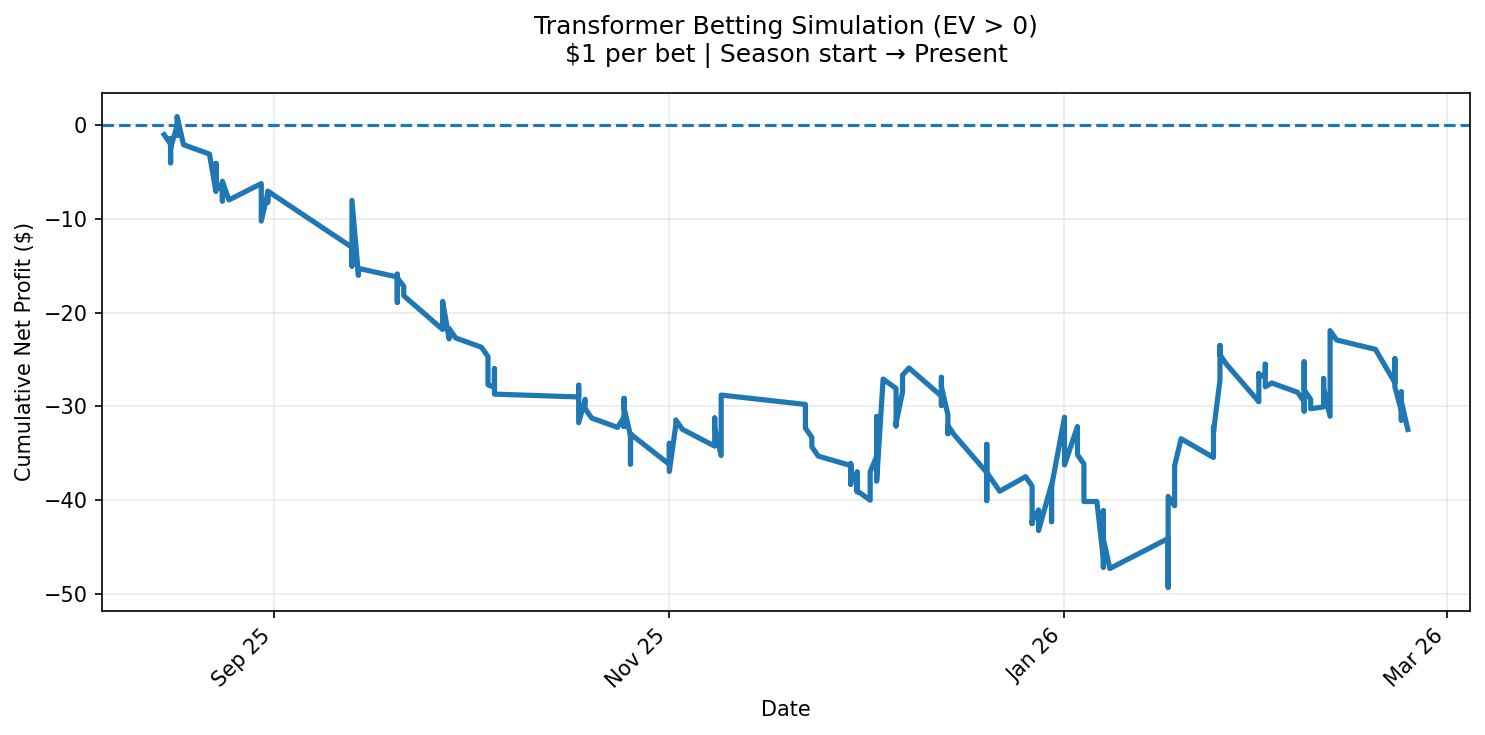

In [6]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# -------------------- find odds cols in df0 --------------------
ODDS_CANDIDATES = [
    ("odds_home","odds_draw","odds_away"),
    ("B365H","B365D","B365A"),
    ("PSH","PSD","PSA"),
    ("WHH","WHD","WHA"),
    ("VCH","VCD","VCA"),
]

def find_odds_triplet(df):
    for h,d,a in ODDS_CANDIDATES:
        if {h,d,a}.issubset(df.columns):
            return (h,d,a)
    return None

odds_cols = find_odds_triplet(df0)
if odds_cols is None:
    raise ValueError("No odds columns found in df0. Need odds_home/odds_draw/odds_away (or B365H/B365D/B365A etc).")

hcol, dcol, acol = odds_cols
print("✅ Using odds columns:", odds_cols)

# -------------------- helpers --------------------
def implied_probs_from_decimal_odds(dec_h, dec_d, dec_a):
    """Decimal odds -> fair probs and overround."""
    if not (np.isfinite(dec_h) and np.isfinite(dec_d) and np.isfinite(dec_a)):
        return None
    p_raw = np.array([1/dec_h, 1/dec_d, 1/dec_a], dtype=float)
    overround = float(p_raw.sum() - 1.0)
    p_fair = p_raw / p_raw.sum()
    return float(p_fair[0]), float(p_fair[1]), float(p_fair[2]), overround

def model_probs_for_batch(home_seq, away_seq, ctx, home_id, away_id):
    """Returns calibrated probs (B, C) using your model+scaler."""
    model.eval(); scaler.eval()
    with torch.no_grad():
        logits = model(home_seq, away_seq, ctx, home_id, away_id)
        logits = scaler(logits)
        return torch.softmax(logits, dim=1)

# In your script, le + class_names exist already
# Ensure we have index mapping for H/D/A
label_to_i = {lab:i for i, lab in enumerate(class_names)}
for lab in ["H","D","A"]:
    if lab not in label_to_i:
        raise ValueError(f"class_names must include {lab}. Got: {class_names}")

# -------------------- main simulation --------------------
def simulate_transformer_bankroll(
    df0,
    data,                 # your built dataset rows (has home_seq/away_seq/ctx/ids/target/match_idx)
    start_date="2026-01-01",
    end_date=None,
    stake=1.0,
    mode="BET_ALL",       # "BET_ALL" or "EV_FILTER"
    edge_thresh=0.03
):
    """
    mode:
      - BET_ALL: bet $1 on model argmax for every eligible match
      - EV_FILTER: pick side with best EV; bet only if EV>0 and edge>=edge_thresh
    """
    if end_date is None:
        end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

    # Pull odds + date + result from df0 using match_idx
    cols_needed = ["date", "ft_result", hcol, dcol, acol]
    missing = [c for c in cols_needed if c not in df0.columns]
    if missing:
        raise ValueError(f"df0 missing columns needed for simulation: {missing}")

    meta = df0.loc[:, cols_needed].copy()
    meta["date"] = pd.to_datetime(meta["date"], errors="coerce")
    meta["ft_result"] = meta["ft_result"].astype(str).str.strip().str.upper()

    # decimal odds numeric
    meta[[hcol, dcol, acol]] = meta[[hcol, dcol, acol]].apply(pd.to_numeric, errors="coerce")

    # Merge into data by match_idx
    sim = data[["match_idx","home_team","away_team","home_seq","away_seq"] + CTX_COLS + ["target"]].copy()
    sim = sim.merge(meta.reset_index(drop=True).reset_index().rename(columns={"index":"match_idx"}), on="match_idx", how="left")

    # Filter date window + rows with odds + result
    sim = sim[(sim["date"] >= pd.to_datetime(start_date)) & (sim["date"] <= pd.to_datetime(end_date))].copy()
    sim = sim.dropna(subset=[hcol,dcol,acol,"date"])
    sim = sim[sim["ft_result"].isin(["H","D","A"])].copy()

    # Build tensors in batches for speed
    # Normalize using your norm_tokens/norm_ctx functions already defined
    # (they exist in your script)
    B = len(sim)
    if B == 0:
        raise ValueError("No matches available in the selected date range after filtering for odds/history.")

    # team ids
    sim["home_id"] = sim["home_team"].map(lambda t: team_to_id[clean_team_name(t)])
    sim["away_id"] = sim["away_team"].map(lambda t: team_to_id[clean_team_name(t)])

    # Create arrays
    home_seq_arr = np.stack([norm_tokens(x).astype(np.float32) for x in sim["home_seq"].values], axis=0)
    away_seq_arr = np.stack([norm_tokens(x).astype(np.float32) for x in sim["away_seq"].values], axis=0)
    ctx_arr      = np.stack([norm_ctx(sim.loc[i, CTX_COLS].to_numpy(dtype=np.float32)).astype(np.float32)
                             for i in sim.index], axis=0)

    # torch tensors
    home_seq_t = torch.from_numpy(home_seq_arr).to(DEVICE)
    away_seq_t = torch.from_numpy(away_seq_arr).to(DEVICE)
    ctx_t      = torch.from_numpy(ctx_arr).to(DEVICE)
    home_id_t  = torch.from_numpy(sim["home_id"].to_numpy(np.int64)).to(DEVICE)
    away_id_t  = torch.from_numpy(sim["away_id"].to_numpy(np.int64)).to(DEVICE)

    # Predict probs
    probs_t = model_probs_for_batch(home_seq_t, away_seq_t, ctx_t, home_id_t, away_id_t)
    probs = probs_t.detach().cpu().numpy()

    # Attach probs columns in H/D/A order
    sim["pH"] = probs[:, label_to_i["H"]]
    sim["pD"] = probs[:, label_to_i["D"]]
    sim["pA"] = probs[:, label_to_i["A"]]

    # Book fair probs + EV/edge
    p_book_H, p_book_D, p_book_A, overrounds = [], [], [], []
    for dh, dd, da in sim[[hcol, dcol, acol]].to_numpy():
        out = implied_probs_from_decimal_odds(float(dh), float(dd), float(da))
        if out is None:
            p_book_H.append(np.nan); p_book_D.append(np.nan); p_book_A.append(np.nan); overrounds.append(np.nan)
        else:
            bh, bd, ba, ov = out
            p_book_H.append(bh); p_book_D.append(bd); p_book_A.append(ba); overrounds.append(ov)

    sim["p_book_H"] = p_book_H
    sim["p_book_D"] = p_book_D
    sim["p_book_A"] = p_book_A
    sim["overround"] = overrounds

    # Choose bet side
    # EV = p_model * dec_odds - 1
    sim["EV_H"] = sim["pH"] * sim[hcol] - 1.0
    sim["EV_D"] = sim["pD"] * sim[dcol] - 1.0
    sim["EV_A"] = sim["pA"] * sim[acol] - 1.0

    sim["edge_H"] = sim["pH"] - sim["p_book_H"]
    sim["edge_D"] = sim["pD"] - sim["p_book_D"]
    sim["edge_A"] = sim["pA"] - sim["p_book_A"]

    def pick_side_row(r):
        if mode == "BET_ALL":
            # bet on argmax probability
            s = np.argmax([r["pH"], r["pD"], r["pA"]])
            return ["H","D","A"][s], True
        else:
            # EV filter: pick highest EV, only bet if EV>0 & edge>=threshold
            evs = {"H": r["EV_H"], "D": r["EV_D"], "A": r["EV_A"]}
            edges = {"H": r["edge_H"], "D": r["edge_D"], "A": r["edge_A"]}
            side = max(evs.items(), key=lambda kv: kv[1])[0]
            do_bet = (evs[side] > 0) and (edges[side] >= float(edge_thresh))
            return side, do_bet

    bet_side = []
    do_bet = []
    for _, r in sim.iterrows():
        s, b = pick_side_row(r)
        bet_side.append(s)
        do_bet.append(b)

    sim["bet_side"] = bet_side
    sim["do_bet"] = do_bet

    # Determine odds for chosen side
    sim["dec_odds"] = np.where(sim["bet_side"]=="H", sim[hcol],
                       np.where(sim["bet_side"]=="D", sim[dcol], sim[acol]))

    # Profit per bet (stake=1): win => (dec-1)*stake, lose => -stake
    def profit_row(r):
        if not r["do_bet"]:
            return 0.0
        if r["ft_result"] == r["bet_side"]:
            return float(stake) * (float(r["dec_odds"]) - 1.0)
        return -float(stake)

    sim["bet_profit"] = sim.apply(profit_row, axis=1)

    # Cum profit over time
    sim = sim.sort_values("date").reset_index(drop=True)
    sim["cum_profit"] = sim["bet_profit"].cumsum()

    # Summary
    n_bets = int(sim["do_bet"].sum())
    total_staked = float(n_bets * stake)
    net_profit = float(sim["cum_profit"].iloc[-1]) if len(sim) else 0.0
    roi = (net_profit / total_staked) if total_staked > 0 else 0.0

    summary = {
        "start_date": str(pd.to_datetime(start_date).date()),
        "end_date": str(pd.to_datetime(end_date).date()),
        "mode": mode,
        "edge_thresh": float(edge_thresh) if mode != "BET_ALL" else None,
        "n_matches_scored": int(len(sim)),
        "n_bets": n_bets,
        "total_staked": total_staked,
        "net_profit": net_profit,
        "ROI": roi,
        "odds_cols_used": (hcol, dcol, acol),
    }
    return summary, sim

summary_ev_season, sim_ev_season = simulate_transformer_bankroll(
    df0=df0,
    data=data,
    start_date="2025-08-01",   # beginning of season
    end_date=None,             # today
    stake=1.0,
    mode="EV_FILTER",
    edge_thresh=0.0            # bet only if EV>0
)

print(summary_ev_season)


import matplotlib.dates as mdates
import matplotlib.pyplot as plt

sim = sim_ev_season.sort_values("date").copy()

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.plot(sim["date"], sim["cum_profit"], linewidth=2.5)
ax.axhline(0, linestyle="--", linewidth=1.5)

ax.set_title("Transformer Betting Simulation (EV > 0)\n$1 per bet | Season start → Present", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Net Profit ($)")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # every 2 months (cleaner)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()